ACTIVIDAD SESIÓN REDES NEURONALES CONVOLUTIVAS
Una empresa de tecnología está desarrollando un sistema de reconocimiento de gestos de manos
para controlar dispositivos mediante visión por computadora. Para ello, necesita entrenar una red
neuronal convolutiva (CNN) que pueda clasificar diferentes posiciones de la mano a partir de
imágenes.
Tu tarea es crear y optimizar una CNN para clasificar imágenes de la base de datos SignMNIST, que
contiene gestos del lenguaje de señas americano (ASL). Este conjunto de datos se encuentra
disponible en la librería TensorFlow Datasets (TFDS).
Para completar la actividad, deberás implementar y entrenar un modelo de CNN, evaluar su
rendimiento y mejorarlo con técnicas de optimización.
INSTRUCCIONES
1. Carga y exploración del dataset (1 punto)
• Cargar el dataset SignMNIST desde TensorFlow Datasets.
• Dividirlo en conjunto de entrenamiento y prueba.
• Normalizar las imágenes para que sus valores estén entre 0 y 1.
• Mostrar algunas imágenes del conjunto de datos con sus etiquetas correspondientes.


In [22]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models



In [23]:

# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)


Path to dataset files: /Users/mateo/.cache/kagglehub/datasets/datamunge/sign-language-mnist/versions/1


In [9]:
# Cargar los archivos CSV
train = pd.read_csv(f"{path}/sign_mnist_train.csv")
test = pd.read_csv(f"{path}/sign_mnist_test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Ver las primeras filas
print(train.head())
print(test.head())
display(train)

Train shape: (27455, 785)
Test shape: (7172, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  p

In [17]:
# normalizar los datos de píxeles
col=train.columns.drop('label')
print(col)
# Etiquetas
y_train = train["label"].values
y_test = test["label"].values

# Píxeles
X_train = train.drop("label", axis=1).values
X_test = test.drop("label", axis=1).values

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=784)


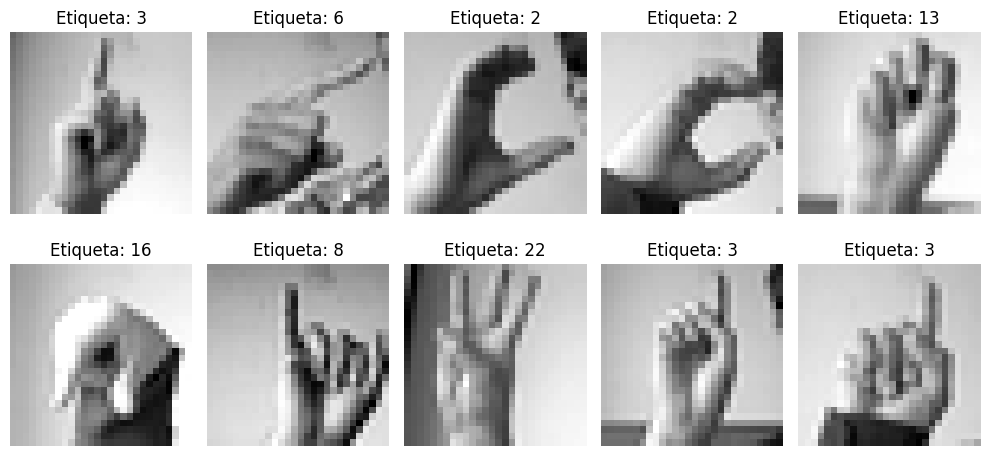

In [20]:
# Mostrar imagenes de ejemplo

# Mostrar las primeras 10 imágenes de entrenamiento
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    # Tomamos la imagen (ya normalizada) y la dejamos en 28x28
    img = X_train[i].reshape(28, 28)
    label = y_train[i]

    ax.imshow(img, cmap="gray")      # imagen en escala de grises
    ax.set_title(f"Etiqueta: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

2. Definición del modelo de Red Neuronal Convolutiva (2 puntos)

• Definir una CNN con al menos tres capas convolucionales.

• Incluir capas de Pooling para reducir la dimensionalidad.

• Aplicar una capa de Flattening antes de la capa densa.

• Agregar al menos una capa densa totalmente conectada y una capa de salida con activación
softmax para clasificación multiclase.


In [19]:
# 4) DEFINIR LA CNN
#   - Conv2D + ReLU: extrae patrones locales (bordes, trazos)
#   - MaxPooling: reduce tamaño y sobreajuste
#   - Flatten + Dense: clasificador final
num_classes = 10

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),                   # (alto, ancho, canales)
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),                               # regularización
    layers.Dense(num_classes, activation="softmax")    # 10 probabilidades
], name="cnn_mnist")

model.summary()

2025-08-29 21:57:59.908979: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-08-29 21:57:59.909472: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-08-29 21:57:59.909499: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-08-29 21:57:59.910149: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-29 21:57:59.910680: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "cnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

3. Compilación y entrenamiento del modelo (2 puntos)

• Compilar el modelo usando la función de pérdida adecuada para clasificación multiclase.

• Entrenar el modelo con un optimizador adecuado.

• Usar early stopping para evitar sobreajuste si es necesario.


In [24]:
# COMPILAR
#   - Pérdida: sparse_categorical_crossentropy (etiquetas enteras 0..9)
#   - Optimizador: Adam
#   - Métrica: accuracy
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# EarlyStopping: parar cuando val_loss no mejora
early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

4. Evaluación del modelo (2 puntos)

• Evaluar la precisión del modelo en el conjunto de prueba.

• Graficar las curvas de precisión y pérdida en las épocas de entrenamiento.

• Generar una matriz de confusión para analizar los errores del modelo.


5. Optimización del modelo (3 puntos)

• Aplicar técnicas de mejora del modelo:

o Aumento de datos (Data Augmentation) para mejorar la generalización.

o Regularización con Dropout para evitar el sobreajuste.

o Cambio de hiperparámetros, como tasa de aprendizaje o número de filtros.

• Comparar el rendimiento del modelo antes y después de la optimización.

• Explicar qué cambios fueron los más efectivos y por qué.